<a href="https://colab.research.google.com/github/samsarkar184/ML-Projects/blob/main/Iris_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Accuracy of the classifier is : 1.0



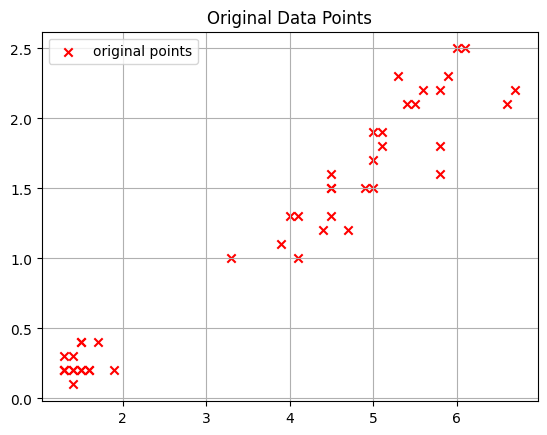

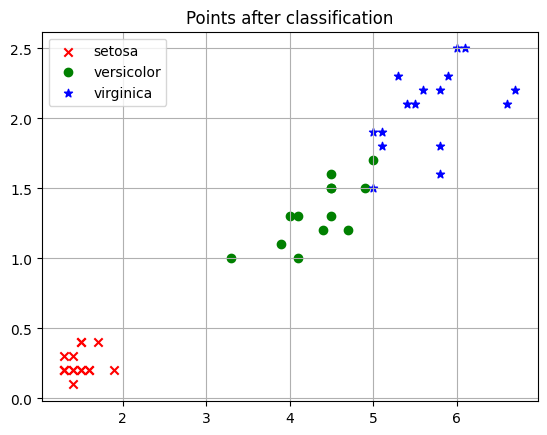

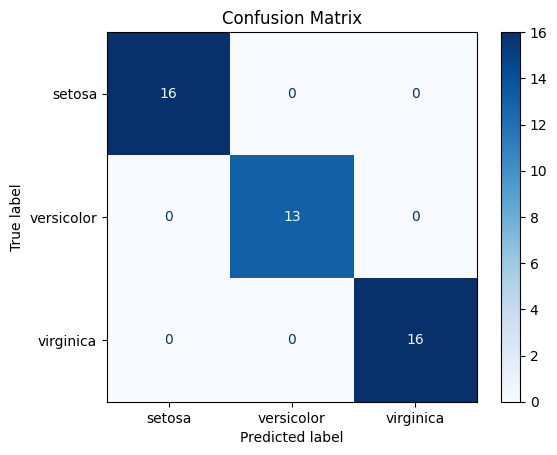


Classification report :

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        16
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        16

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



'\n#-------------------------------------------------------\n# Taking user input for testing\n#-------------------------------------------------------\n\nprint("\nEnter flower features:")\n\nsepal_length=float(input("Enter sepal length : "))\nsepal_width=float(input("Enter sepal width : "))\npetal_length=float(input("Enter petal length : "))\npetal_width=float(input("Enter petal width : "))\n\n\n#-------------------------------------------------------\n# Creating test sample\n#-------------------------------------------------------\nuser_data=np.array([[sepal_length,sepal_width,petal_length,petal_width]])\n\n\n#-------------------------------------------------------\n# Predicting class\n#-------------------------------------------------------\nprediction=bayes_maximum_likelihood_classifier(X_train,y_train,user_data)\n\n\n#-------------------------------------------------------\n# Displaying result\n#-------------------------------------------------------\nprint()\n\nif prediction[0]==0

In [3]:
#===============================================================================
# Classification of Iris Dataset with Bayes Maximum Likelihood Classifier
#===============================================================================


#-------------------------------------------------------
# Importing Libraries
#-------------------------------------------------------
import numpy as np
from scipy.stats import multivariate_normal
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report


#-------------------------------------------------------
# Classifier Function definition
#-------------------------------------------------------
def bayes_maximum_likelihood_classifier(X_train,y_train,X_test):


  #-----------------------------------------------------
  #separation of data according to class
  #-----------------------------------------------------
  X_setosa=X_train[y_train==0]
  X_versicolor=X_train[y_train==1]
  X_virginica=X_train[y_train==2]

  #-----------------------------------------------------
  #computation of mean for different classes
  #-----------------------------------------------------
  mean_setosa=np.mean(X_setosa,axis=0)
  mean_versicolor=np.mean(X_versicolor,axis=0)
  mean_virginica=np.mean(X_virginica,axis=0)

  #-----------------------------------------------------
  # Computation of covariance Matrices
  #-----------------------------------------------------
  cov_setosa=np.cov(X_setosa,rowvar=False)
  cov_versicolor=np.cov(X_versicolor,rowvar=False)
  cov_virginica=np.cov(X_virginica,rowvar=False)

  #-----------------------------------------------------
  #computation of probability density of different classes
  #-----------------------------------------------------
  pdf_setosa=multivariate_normal(mean=mean_setosa,cov=cov_setosa)
  pdf_versicolor=multivariate_normal(mean=mean_versicolor,cov=cov_versicolor)
  pdf_virginica=multivariate_normal(mean=mean_virginica,cov=cov_virginica)
  y_pred=[]

  #-----------------------------------------------------
  #computation of likelihood for different classes
  #-----------------------------------------------------
  for x in X_test:
    likelihood_setosa=pdf_setosa.pdf(x)
    likelihood_versicolor=pdf_versicolor.pdf(x)
    likelihood_virginica=pdf_virginica.pdf(x)

    #----------------------------------------------------------
    # Assigning points to different classes based on likelihood
    #----------------------------------------------------------
    if likelihood_setosa>likelihood_versicolor and likelihood_setosa>likelihood_virginica:
      y_pred.append(0)
    elif likelihood_versicolor>likelihood_setosa and likelihood_versicolor>likelihood_virginica:
      y_pred.append(1)
    else:
      y_pred.append(2)
  return y_pred

#------------------------------------------------------
#Loading Iris Data
#------------------------------------------------------
iris=load_iris()
X=iris.data
y=iris.target


#-------------------------------------------------------
#shuffle the data
#-------------------------------------------------------
indices=np.random.permutation(len(X))
X=X[indices]
y=y[indices]

#-------------------------------------------------------
# Splitting the data
#-------------------------------------------------------
train_size=int(0.7*len(X))
X_train,X_test,y_train,y_test=X[:train_size],X[train_size:],y[:train_size],y[train_size:]
y_pred=bayes_maximum_likelihood_classifier(X_train,y_train,X_test)


#-------------------------------------------------------
# Accuracy of the classifier
#-------------------------------------------------------
accuracy=np.mean(y_pred==y_test)
y_pred=np.array(y_pred)
print("\nAccuracy of the classifier is :",accuracy)


#-------------------------------------------------------
#Plotting original data points
#-------------------------------------------------------
plt.scatter(X_test[:,2],X_test[:,3],c='red',marker='x',label='original points')
print()
plt.legend()
plt.title("Original Data Points")
plt.grid(True)
plt.show()

#-------------------------------------------------------
#Plotting data points after classification
#-------------------------------------------------------
plt.scatter(X_test[y_pred==0][:,2],X_test[y_pred==0][:,3],c='red',marker='x',label='setosa')
plt.scatter(X_test[y_pred==1][:,2],X_test[y_pred==1][:,3],c='green',marker='o',label='versicolor')
plt.scatter(X_test[y_pred==2][:,2],X_test[y_pred==2][:,3],c='blue',marker='*',label='virginica')
print()
plt.title("Points after classification")
plt.legend()
plt.grid(True)
plt.show()


#-------------------------------------------------------
# Confusion Matrix
#-------------------------------------------------------
cm=confusion_matrix(y_test,y_pred)
disp=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=iris.target_names)
print()
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()


#-------------------------------------------------------
# Classification report
#-------------------------------------------------------
report=classification_report(y_test,y_pred,target_names=iris.target_names)
print()
print("Classification report :")
print()
print(report)

#-------------------------------------------------------
# Taking user input for testing
#-------------------------------------------------------

print("\nEnter flower features:")

sepal_length=float(input("Enter sepal length : "))
sepal_width=float(input("Enter sepal width : "))
petal_length=float(input("Enter petal length : "))
petal_width=float(input("Enter petal width : "))


#-------------------------------------------------------
# Creating test sample
#-------------------------------------------------------
user_data=np.array([[sepal_length,sepal_width,petal_length,petal_width]])


#-------------------------------------------------------
# Predicting class
#-------------------------------------------------------
prediction=bayes_maximum_likelihood_classifier(X_train,y_train,user_data)


#-------------------------------------------------------
# Displaying result
#-------------------------------------------------------
print()

if prediction[0]==0:
  print("Predicted class : Setosa")

elif prediction[0]==1:
  print("Predicted class : Versicolor")

else:
  print("Predicted class : Virginica")